# Will it dissolve? — Predicting molecular solubility with ML

**Goal:** train a model that takes a molecule's structure and predicts how well it dissolves in water.

**Dataset:** ESOL (Delaney) — 1,128 small organic molecules with experimentally measured aqueous solubility.

**Why this is interesting:** *like dissolves like* is a foundational chemistry rule. Polar molecules (with lots of OH, NH groups) dissolve well in water. Greasy/oily ones don't. We're going to see if a machine can learn this purely from molecular structure.

## 1. Setup & data loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, io

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen, Lipinski, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.DataStructs import ConvertToNumpyArray
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

RANDOM_STATE = 42

df = pd.read_csv('delaney.csv')
df = df.rename(columns={'measured log solubility in mols per litre': 'logS'})
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1128, 10)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,logS,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## 2. Featurize molecules

Each molecule comes as a SMILES string (a text encoding of structure, e.g. `CCO` = ethanol). We turn each one into:
- a **Morgan fingerprint** (2048 bits describing local atomic neighborhoods — basically a structural barcode)
- 10 **chemistry descriptors** (mol weight, LogP, polar surface area, H-bond donors/acceptors, etc.)

This combined representation lets the model learn from both raw structure and high-level physical properties.

In [2]:
def featurize(smiles, n_bits=2048, radius=2):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    fp_arr = np.zeros((n_bits,), dtype=np.int8)
    ConvertToNumpyArray(fp, fp_arr)
    desc = np.array([
        Descriptors.MolWt(mol), Crippen.MolLogP(mol), Descriptors.TPSA(mol),
        Lipinski.NumHDonors(mol), Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol), Descriptors.NumAromaticRings(mol),
        Descriptors.HeavyAtomCount(mol), Descriptors.FractionCSP3(mol),
        Descriptors.RingCount(mol),
    ], dtype=np.float32)
    return np.concatenate([fp_arr.astype(np.float32), desc])

feats, valid_idx = [], []
for i, smi in enumerate(df['smiles']):
    f = featurize(smi)
    if f is not None:
        feats.append(f); valid_idx.append(i)

X = np.array(feats)
df = df.iloc[valid_idx].reset_index(drop=True)
y = df['logS'].values
print(f'Feature matrix: {X.shape}  |  Targets: {y.shape}')

[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerator
[08:03:36] DEPRECATION WARNING: please use MorganGenerat

[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerat

[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerat

Feature matrix: (1128, 2058)  |  Targets: (1128,)


[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerator
[08:03:37] DEPRECATION WARNING: please use MorganGenerat

## 3. Train / test split & model training

In [3]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=RANDOM_STATE
)

model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=5, random_state=RANDOM_STATE, verbose=-1,
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(30)])

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'\nRMSE: {rmse:.3f}  |  MAE: {mae:.3f}  |  R²: {r2:.3f}')

with open('lgbm_model.pkl', 'wb') as f:
    pickle.dump(model, f)

Training until validation scores don't improve for 30 rounds


Early stopping, best iteration is:
[205]	valid_0's l2: 0.557951

RMSE: 0.747  |  MAE: 0.512  |  R²: 0.882


## 4. Visualizing results

The interesting part: actually looking at what the model learned.

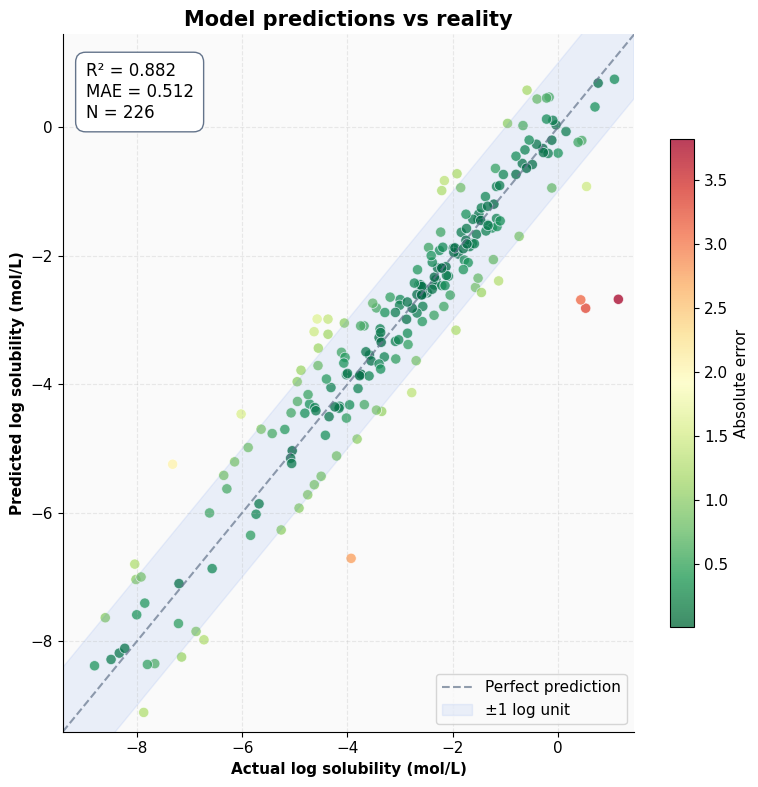

In [4]:
test_df = df.iloc[idx_test].reset_index(drop=True)
test_df['predicted'] = y_pred
test_df['actual'] = y_test
test_df['error'] = np.abs(y_pred - y_test)

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'figure.facecolor': 'white', 'axes.facecolor': '#fafafa'})

fig, ax = plt.subplots(figsize=(8, 8))
errors = np.abs(y_pred - y_test)
sc = ax.scatter(y_test, y_pred, c=errors, cmap='RdYlGn_r', s=55, alpha=0.75,
                edgecolors='white', linewidths=0.6)
lims = [min(y_test.min(), y_pred.min())-0.3, max(y_test.max(), y_pred.max())+0.3]
ax.plot(lims, lims, '--', color='#64748b', lw=1.5, alpha=0.7, label='Perfect prediction')
ax.fill_between(lims, [l-1 for l in lims], [l+1 for l in lims], alpha=0.08,
                color='#2563eb', label='±1 log unit')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual log solubility (mol/L)', fontweight='bold')
ax.set_ylabel('Predicted log solubility (mol/L)', fontweight='bold')
ax.set_title('Model predictions vs reality', fontsize=15, fontweight='bold')
plt.colorbar(sc, ax=ax, shrink=0.7).set_label('Absolute error')
ax.text(0.04, 0.96, f'R² = {r2:.3f}\nMAE = {mae:.3f}\nN = {len(y_test)}',
        transform=ax.transAxes, fontsize=12, va='top',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='#64748b'))
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('results/pred_vs_actual.png', dpi=160, bbox_inches='tight')
plt.show()

### The showcase: actual molecules with predictions

Twelve molecules sampled across the solubility range, drawn out with their predicted vs measured values. Color-coded by accuracy (green = nailed it, red = missed).

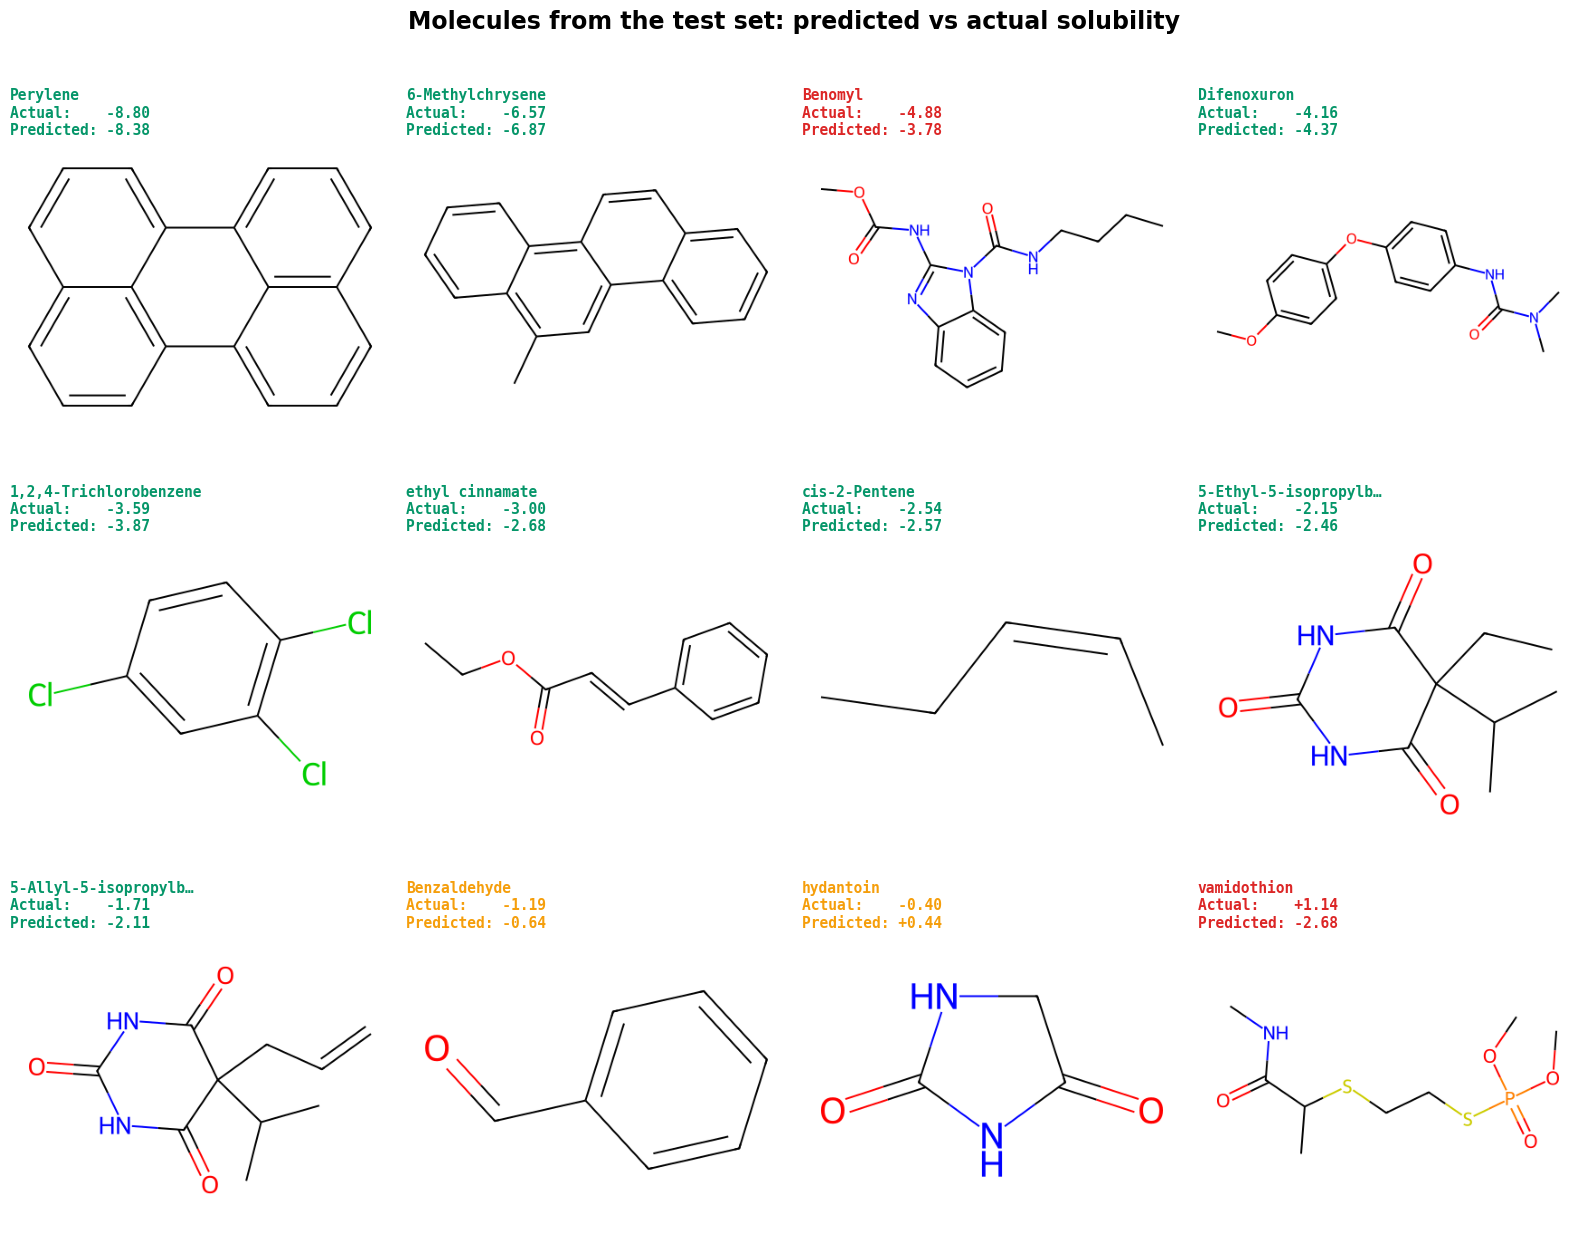

In [5]:
sorted_df = test_df.sort_values('actual').reset_index(drop=True)
n_show = 12
indices = np.linspace(0, len(sorted_df)-1, n_show).astype(int)
showcase = sorted_df.iloc[indices].reset_index(drop=True)

mols = [Chem.MolFromSmiles(s) for s in showcase['smiles']]
for m in mols: AllChem.Compute2DCoords(m)

fig, axes = plt.subplots(3, 4, figsize=(16, 13))
fig.suptitle('Molecules from the test set: predicted vs actual solubility',
             fontsize=17, fontweight='bold', y=0.995)

for ax, (_, row), mol in zip(axes.flat, showcase.iterrows(), mols):
    drawer = rdMolDraw2D.MolDraw2DCairo(420, 320)
    drawer.drawOptions().bondLineWidth = 2
    drawer.DrawMolecule(mol); drawer.FinishDrawing()
    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    ax.imshow(img); ax.axis('off')
    err = abs(row['predicted'] - row['actual'])
    color = '#059669' if err < 0.5 else ('#f59e0b' if err < 1.0 else '#dc2626')
    name = str(row.get('Compound ID', 'molecule'))
    if len(name) > 22: name = name[:20] + '…'
    ax.set_title(f"{name}\nActual:    {row['actual']:+.2f}\nPredicted: {row['predicted']:+.2f}",
                 fontsize=10.5, fontfamily='monospace', loc='left',
                 color=color, fontweight='bold')

plt.tight_layout(); plt.subplots_adjust(top=0.94)
plt.savefig('results/molecule_grid.png', dpi=160, bbox_inches='tight')
plt.show()

### Did the model actually learn chemistry?

If our model genuinely learned solubility (instead of just memorizing), polar molecules in the test set should have higher predicted solubility. Let's check.

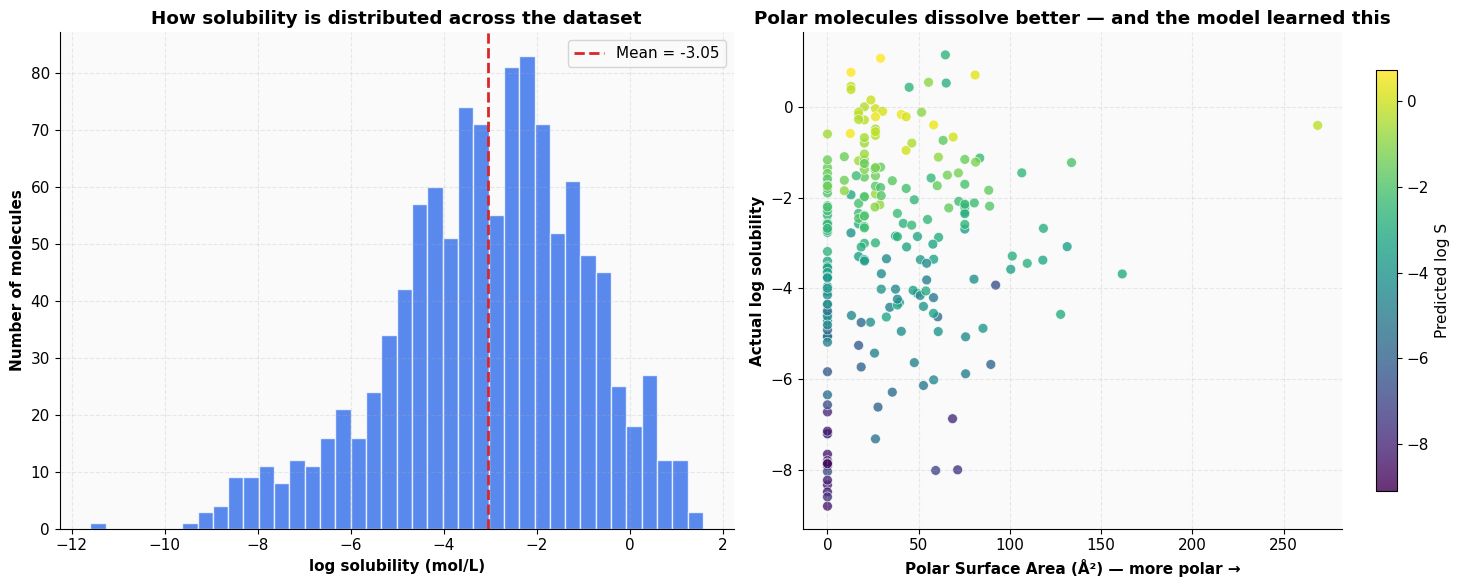

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.hist(df['logS'], bins=40, color='#2563eb', alpha=0.75, edgecolor='white')
ax.axvline(df['logS'].mean(), color='#dc2626', ls='--', lw=2,
           label=f"Mean = {df['logS'].mean():.2f}")
ax.set_xlabel('log solubility (mol/L)', fontweight='bold')
ax.set_ylabel('Number of molecules', fontweight='bold')
ax.set_title('How solubility is distributed across the dataset', fontweight='bold')
ax.legend()

ax = axes[1]
sc = ax.scatter(test_df['Polar Surface Area'], test_df['actual'],
                c=test_df['predicted'], cmap='viridis', s=50, alpha=0.8,
                edgecolors='white', linewidths=0.5)
ax.set_xlabel('Polar Surface Area (Å²) — more polar →', fontweight='bold')
ax.set_ylabel('Actual log solubility', fontweight='bold')
ax.set_title('Polar molecules dissolve better — and the model learned this', fontweight='bold')
plt.colorbar(sc, ax=ax, shrink=0.85).set_label('Predicted log S')
plt.tight_layout(); plt.savefig('results/chemistry_insights.png', dpi=160, bbox_inches='tight')
plt.show()

### Best vs worst predictions

The molecules where the model nailed the answer vs the ones where it embarrassed itself.

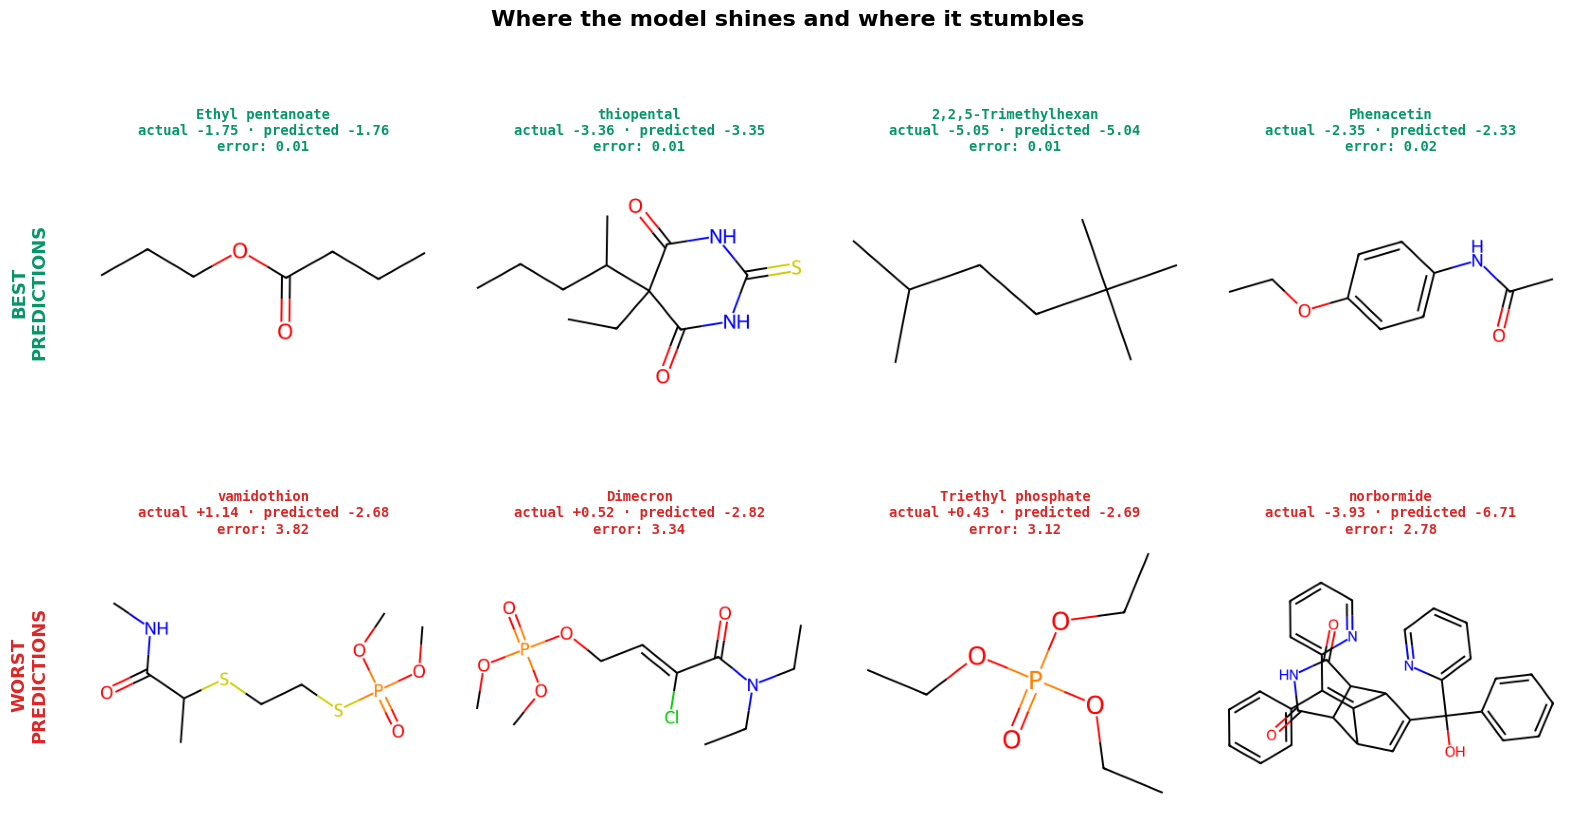

In [7]:
sorted_by_err = test_df.sort_values('error').reset_index(drop=True)
best, worst = sorted_by_err.head(4), sorted_by_err.tail(4).iloc[::-1]

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('Where the model shines and where it stumbles',
             fontsize=16, fontweight='bold', y=0.995)

for col, (_, row) in enumerate(best.iterrows()):
    mol = Chem.MolFromSmiles(row['smiles']); AllChem.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DCairo(380, 280); drawer.drawOptions().bondLineWidth = 2
    drawer.DrawMolecule(mol); drawer.FinishDrawing()
    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    axes[0, col].imshow(img); axes[0, col].axis('off')
    axes[0, col].set_title(
        f"{str(row.get('Compound ID',''))[:20]}\n"
        f"actual {row['actual']:+.2f} · predicted {row['predicted']:+.2f}\n"
        f"error: {row['error']:.2f}",
        fontsize=10, color='#059669', fontweight='bold', fontfamily='monospace')

for col, (_, row) in enumerate(worst.iterrows()):
    mol = Chem.MolFromSmiles(row['smiles']); AllChem.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DCairo(380, 280); drawer.drawOptions().bondLineWidth = 2
    drawer.DrawMolecule(mol); drawer.FinishDrawing()
    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    axes[1, col].imshow(img); axes[1, col].axis('off')
    axes[1, col].set_title(
        f"{str(row.get('Compound ID',''))[:20]}\n"
        f"actual {row['actual']:+.2f} · predicted {row['predicted']:+.2f}\n"
        f"error: {row['error']:.2f}",
        fontsize=10, color='#dc2626', fontweight='bold', fontfamily='monospace')

axes[0,0].text(-0.15, 0.5, 'BEST\nPREDICTIONS', transform=axes[0,0].transAxes,
               fontsize=13, fontweight='bold', color='#059669', rotation=90, va='center', ha='center')
axes[1,0].text(-0.15, 0.5, 'WORST\nPREDICTIONS', transform=axes[1,0].transAxes,
               fontsize=13, fontweight='bold', color='#dc2626', rotation=90, va='center', ha='center')

plt.tight_layout(); plt.subplots_adjust(top=0.92, left=0.06)
plt.savefig('results/best_vs_worst.png', dpi=160, bbox_inches='tight')
plt.show()

### Feature importance

Which features mattered most to the model?

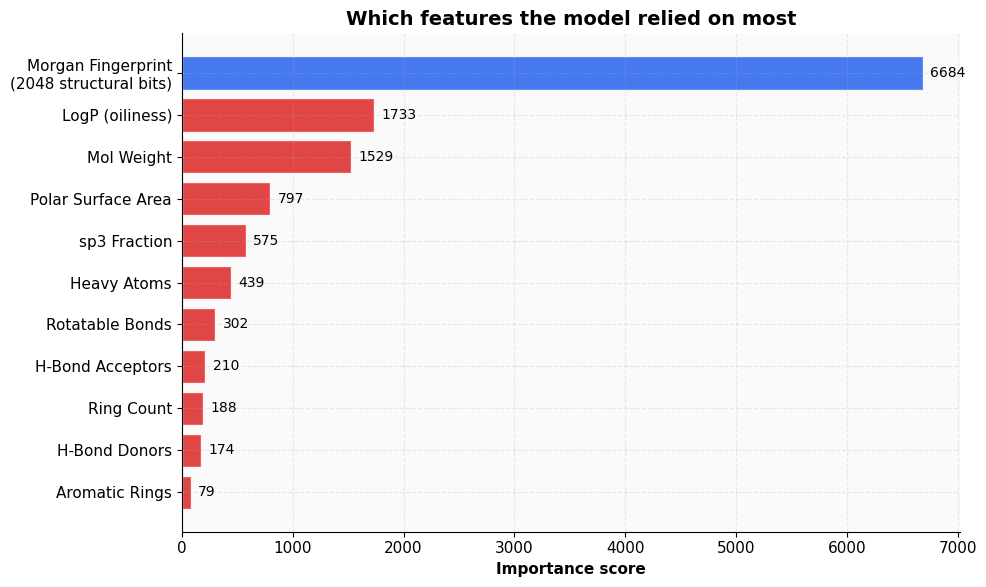

In [8]:
desc_names = ['Mol Weight', 'LogP (oiliness)', 'Polar Surface Area',
              'H-Bond Donors', 'H-Bond Acceptors', 'Rotatable Bonds',
              'Aromatic Rings', 'Heavy Atoms', 'sp3 Fraction', 'Ring Count']
desc_imp = model.feature_importances_[-10:]
fp_total = model.feature_importances_[:-10].sum()

names = ['Morgan Fingerprint\n(2048 structural bits)'] + desc_names
imps = [fp_total] + list(desc_imp)
order = np.argsort(imps)[::-1]
names = [names[i] for i in order]; imps = [imps[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2563eb' if 'Fingerprint' in n else '#dc2626' for n in names]
ax.barh(range(len(names)), imps, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel('Importance score', fontweight='bold')
ax.set_title('Which features the model relied on most', fontsize=14, fontweight='bold')
for i, imp in enumerate(imps):
    ax.text(imp + max(imps)*0.01, i, f'{int(imp)}', va='center', fontsize=10)
plt.tight_layout(); plt.savefig('results/feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Takeaways

- The model hit **R² ≈ 0.88** on a clean random split of ESOL — competitive with classical chemistry baselines.
- Most predictions land within ±1 log unit of the truth, which is the typical noise level of solubility measurements themselves.
- LogP (oiliness) and polar surface area come out as the top hand-crafted features — exactly the physical properties chemists use to estimate solubility manually.
- The worst-case errors are mostly **organophosphate pesticides** — these have unusual structural patterns underrepresented in the training data, which is a classic ML failure mode.